# BANK LOAN ANALYSIS REPORT

### Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle  # Import Circle from matplotlib.patches
import seaborn as sns
import warnings
import plotly.express as px

In [ ]:
df = pd.read_excel("C:/Users/pavan/OneDrive/financial_loan_data.xlsx")

In [114]:
df.head()

,id,address_state,application_type,emp_length,emp_title,grade,home_ownership,issue_date,last_credit_pull_date,last_payment_date,...,sub_grade,term,verification_status,annual_income,dti,installment,int_rate,loan_amount,total_acc,total_payment
0,1077430,GA,INDIVIDUAL,< 1 year,Ryder,C,RENT,2025-02-11,2025-09-13,2025-04-13,...,C4,60 months,Source Verified,30000.0,0.0100,59.83,0.1527,2500,4,1009
1,1072053,CA,INDIVIDUAL,9 years,MKC Accounting,E,RENT,2025-01-01,2025-12-14,2025-01-15,...,E1,36 months,Source Verified,48000.0,0.0535,109.43,0.1864,3000,4,3939
2,1069243,CA,INDIVIDUAL,4 years,Chemat Technology Inc,C,RENT,2025-01-05,2025-12-12,2025-01-09,...,C5,36 months,Not Verified,50000.0,0.2088,421.65,0.1596,12000,11,3522
3,1041756,TX,INDIVIDUAL,< 1 year,barnes distribution,B,MORTGAGE,2025-02-25,2025-12-12,2025-03-12,...,B2,60 months,Source Verified,42000.0,0.0540,97.06,0.1065,4500,9,4911
4,1068350,IL,INDIVIDUAL,10+ years,J&J Steel Inc,A,MORTGAGE,2025-01-01,2025-12-14,2025-01-15,...,A1,36 months,Verified,83000.0,0.0231,106.53,0.0603,3500,28,3835


In [115]:
df.tail()

,id,address_state,application_type,emp_length,emp_title,grade,home_ownership,issue_date,last_credit_pull_date,last_payment_date,...,sub_grade,term,verification_status,annual_income,dti,installment,int_rate,loan_amount,total_acc,total_payment
38571,803452,NJ,INDIVIDUAL,< 1 year,Joseph M Sanzari Company,C,MORTGAGE,2025-07-11,2025-05-16,2025-05-16,...,C1,60 months,Verified,100000.0,0.1986,551.64,0.1299,24250,33,31946
38572,970377,NY,INDIVIDUAL,8 years,Swat Fame,C,RENT,2025-10-11,2025-04-16,2025-05-16,...,C1,60 months,Verified,50000.0,0.0458,579.72,0.1349,25200,18,31870
38573,875376,CA,INDIVIDUAL,5 years,Anaheim Regional Medical Center,D,RENT,2025-09-11,2025-05-16,2025-05-16,...,D5,60 months,Verified,65000.0,0.1734,627.93,0.1749,25000,20,35721
38574,972997,NY,INDIVIDUAL,5 years,Brooklyn Radiology,D,RENT,2025-10-11,2025-05-16,2025-05-16,...,D5,60 months,Verified,368000.0,0.0009,612.72,0.1825,24000,9,33677
38575,682952,NY,INDIVIDUAL,4 years,Allen Edmonds,F,RENT,2025-07-11,2025-05-16,2025-05-16,...,F3,60 months,Verified,80000.0,0.0600,486.86,0.2099,18000,7,27679


### Metadata of Data

In [116]:
print("NO.of rows:", df.shape[0])

NO.of rows: 38576


In [117]:
print("No.of columns",df.shape[1])

No.of columns 24


In [118]:
df.info

<bound method DataFrame.info of             id address_state application_type emp_length  \
0      1077430            GA       INDIVIDUAL   < 1 year   
1      1072053            CA       INDIVIDUAL    9 years   
2      1069243            CA       INDIVIDUAL    4 years   
3      1041756            TX       INDIVIDUAL   < 1 year   
4      1068350            IL       INDIVIDUAL  10+ years   
...        ...           ...              ...        ...   
38571   803452            NJ       INDIVIDUAL   < 1 year   
38572   970377            NY       INDIVIDUAL    8 years   
38573   875376            CA       INDIVIDUAL    5 years   
38574   972997            NY       INDIVIDUAL    5 years   
38575   682952            NY       INDIVIDUAL    4 years   

                             emp_title grade home_ownership issue_date  \
0                                Ryder     C           RENT 2025-02-11   
1                       MKC Accounting     E           RENT 2025-01-01   
2                Chemat T

### Data Types

In [119]:
df.dtypes

id                                int64
address_state                    object
application_type                 object
emp_length                       object
emp_title                        object
grade                            object
home_ownership                   object
issue_date               datetime64[ns]
last_credit_pull_date    datetime64[ns]
last_payment_date        datetime64[ns]
loan_status                      object
next_payment_date        datetime64[ns]
member_id                         int64
purpose                          object
sub_grade                        object
term                             object
verification_status              object
annual_income                   float64
dti                             float64
installment                     float64
int_rate                        float64
loan_amount                       int64
total_acc                         int64
total_payment                     int64
dtype: object

In [120]:
df.describe()

,id,issue_date,last_credit_pull_date,last_payment_date,next_payment_date,member_id,annual_income,dti,installment,int_rate,loan_amount,total_acc,total_payment
count,3.857600e+04,38576,38576,38576,38576,3.857600e+04,3.857600e+04,38576.000000,38576.000000,38576.000000,38576.000000,38576.000000,38576.000000
mean,6.810371e+05,2025-07-16 02:31:35.562007296,2025-06-08 13:22:56.690169856,2025-06-26 09:52:08.909166080,2025-06-24 12:59:09.979261440,8.476515e+05,6.964454e+04,0.133274,326.862965,0.120488,11296.066855,22.132544,12263.348533
min,5.473400e+04,2025-01-01 00:00:00,2025-01-08 00:00:00,2025-01-08 00:00:00,2025-01-08 00:00:00,7.069900e+04,4.000000e+03,0.000000,15.690000,0.054200,500.000000,2.000000,34.000000
25%,5.135170e+05,2025-04-11 00:00:00,2025-04-15 00:00:00,2025-03-16 00:00:00,2025-04-10 00:00:00,6.629788e+05,4.150000e+04,0.082100,168.450000,0.093200,5500.000000,14.000000,5633.000000
50%,6.627280e+05,2025-07-11 00:00:00,2025-05-16 00:00:00,2025-06-14 00:00:00,2025-06-16 00:00:00,8.473565e+05,6.000000e+04,0.134200,283.045000,0.118600,10000.000000,20.000000,10042.000000
75%,8.365060e+05,2025-10-11 00:00:00,2025-08-13 00:00:00,2025-09-15 00:00:00,2025-09-14 00:00:00,1.045652e+06,8.320050e+04,0.185900,434.442500,0.145900,15000.000000,29.000000,16658.000000
max,1.077501e+06,2025-12-12 00:00:00,2025-12-15 00:00:00,2025-12-15 00:00:00,2025-12-15 00:00:00,1.314167e+06,6.000000e+06,0.299900,1305.190000,0.245900,35000.000000,90.000000,58564.000000
std,2.113246e+05,NaN,NaN,NaN,NaN,2.668105e+05,6.429368e+04,0.066662,209.092000,0.037164,7460.746022,11.392282,9051.104777


### Total Loan Applications

In [121]:
total_loan_application = df ['id'].count()
print("Total Loan Applications",total_loan_application)

Total Loan Applications 38576


### MTD Total Loan Applications

In [122]:
latest_issue_date = df['issue_date'].max()
latest_year = latest_issue_date.year
latest_month = latest_issue_date.month
mtd_data = df[(df['issue_date'].dt.year == latest_year) & (df['issue_date'].dt.month == latest_month)]
mtd_loan_applications = mtd_data['id'].count()
print(f"MTD Loan Applications(for {latest_issue_date.strftime('%B %Y')}):{mtd_loan_applications}")

MTD Loan Applications(for December 2025):4314


### Total Funded Amount

In [123]:
total_funded_amount = df['loan_amount'].sum()
print("Total Funded Amount: ",total_funded_amount)

Total Funded Amount:  435757075


In [210]:
total_funded_amount = df['loan_amount'].sum()
total_funded_amount_in_millions = total_funded_amount/1000000
print("Total Funded Amount: ₹{:.2f}M ".format(total_funded_amount_in_millions))

Total Funded Amount: ₹435.76M 


### MTD- Total Funded Amount

In [211]:
latest_issue_date = df['issue_date'].max()
latest_year = latest_issue_date.year
latest_month = latest_issue_date.month
mtd_data = df[(df['issue_date'].dt.year == latest_year) & (df['issue_date'].dt.month == latest_month)]
mtd_total_funded_amount = mtd_data['loan_amount'].sum()
mtd_total_funded_amount_in_millions = mtd_total_funded_amount/1000000
print("MTD Total Funded Amount: ₹{:.2f}M".format(mtd_total_funded_amount_in_millions))

MTD Total Funded Amount: ₹53.98M


### Total Amount Recieved

In [212]:
total_amount_recieved = df['total_payment'].sum()
total_amount_recieved_in_millions = total_amount_recieved/1000000
print("Total A mount Recieved: ₹{:.2f}M".format(total_amount_recieved_in_millions))

Total A mount Recieved: ₹473.07M


### Total Amount Recieved

In [213]:
latest_issue_date =df['issue_date'].max()
latest_year = latest_issue_date.year
latest_month = latest_issue_date.month
mtd_data =df[(df['issue_date'].dt.year == latest_year) & (df['issue_date'].dt.month == latest_month)]

mtd_total_amount_recieved = mtd_data['total_payment'].sum()
mtd_total_amount_recieved_in_millions = mtd_total_amount_recieved/1000000
print("MTD Total Amount Recieved: ₹{:.2f}M".format(mtd_total_amount_recieved_in_millions))

MTD Total Amount Recieved: ₹58.07M


### Average Interest Rate

In [214]:
averege_interest_rate = df['int_rate'].mean()*100
print("Averege Interest Rate In Percentage: ₹{:.2f}%".format(averege_interest_rate))

Averege Interest Rate In Percentage: ₹12.05%


### MTD Average Interest

In [215]:
latest_issue_date =df['issue_date'].max()
latest_year = latest_issue_date.year
latest_month = latest_issue_date.month
mtd_data =df[(df['issue_date'].dt.year == latest_year) & (df['issue_date'].dt.month == latest_month)]

mtd_averege_interest_rate = mtd_data['int_rate'].mean()*100
print("MTD Averege Interest Rate In Percentage: ₹{:.2f}%".format(mtd_averege_interest_rate))

MTD Averege Interest Rate In Percentage: ₹12.36%


### Averege Debt-To-Income Ratio (DTI):

In [216]:
averege_debt_to_income_ratio = df['dti'].mean()*100
print("Averege Debt To Income Ratio In Percentage: ₹{:.2f}%".format(averege_debt_to_income_ratio))

Averege Debt To Income Ratio In Percentage: ₹13.33%


In [217]:
latest_issue_date =df['issue_date'].max()
latest_year = latest_issue_date.year
latest_month = latest_issue_date.month
mtd_data =df[(df['issue_date'].dt.year == latest_year) & (df['issue_date'].dt.month == latest_month)]

mtd_averege_dti = mtd_data['dti'].mean()*100
print("MTD Averege Debt-To-Income Ratio In Percentage: ₹{:.2f}%".format(mtd_averege_dti))

MTD Averege Debt-To-Income Ratio In Percentage: ₹13.67%


### Good loan Matrics

In [218]:
good_loans =df[df['loan_status'].isin(["Fully Paid","Current"])] #good loans
total_loan_applications = df['id'].sum()
good_loan_application = good_loans['id'].sum()
good_loan_funded_amount = good_loans['loan_amount'].sum()
good_loan_received_amount = good_loans['total_payment'].sum()
good_loan_funded_amount_in_millions = good_loan_funded_amount/1000000
good_loan_received_amount_in_millions = good_loan_received_amount/1000000
good_loan_percentage = (good_loan_application/total_loan_applications)*100
print("Good Loan Application (in millions):",good_loan_application)
print("Good Loan Funded Amount: ₹{:.2f}M".format(good_loan_funded_amount_in_millions))
print("Good Loan Received Amount: ₹{:.2f}M".format(good_loan_received_amount_in_millions))
print("Good Loan Percentage Applications: {:.2f}%".format(good_loan_percentage))

Good Loan Application (in millions): 22561269550
Good Loan Funded Amount: ₹370.22M
Good Loan Received Amount: ₹435.79M
Good Loan Percentage Applications: 85.88%


### Bad Loan Matrics

In [219]:
bad_loans =df[df['loan_status'].isin(["Charged Off"])] #bad loans
total_loan_applications =df['id'].count()
bad_loan_application = bad_loans['id'].count()
bad_loan_funded_amount = bad_loans['loan_amount'].sum()
bad_loan_received_amount = bad_loans['total_payment'].sum()
bad_loan_funded_amount_in_millions = bad_loan_funded_amount/1000000
bad_loan_received_amount_in_millions = bad_loan_received_amount/1000000
bad_loan_percentage = (bad_loan_application/total_loan_applications)*100

print("bad Loan Application (in millions):",bad_loan_application)
print("bad Loan Funded Amount: ₹{:.2f}M".format(bad_loan_funded_amount_in_millions))
print("bad Loan Received Amount: ₹{:.2f}M".format(bad_loan_received_amount_in_millions))
print("bad Loan Percentage Applications: {:.2f}%".format(bad_loan_percentage))

bad Loan Application (in millions): 5333
bad Loan Funded Amount: ₹65.53M
bad Loan Received Amount: ₹37.28M
bad Loan Percentage Applications: 13.82%


###  Monthly Trends By Issue Date For Total Funded Amount

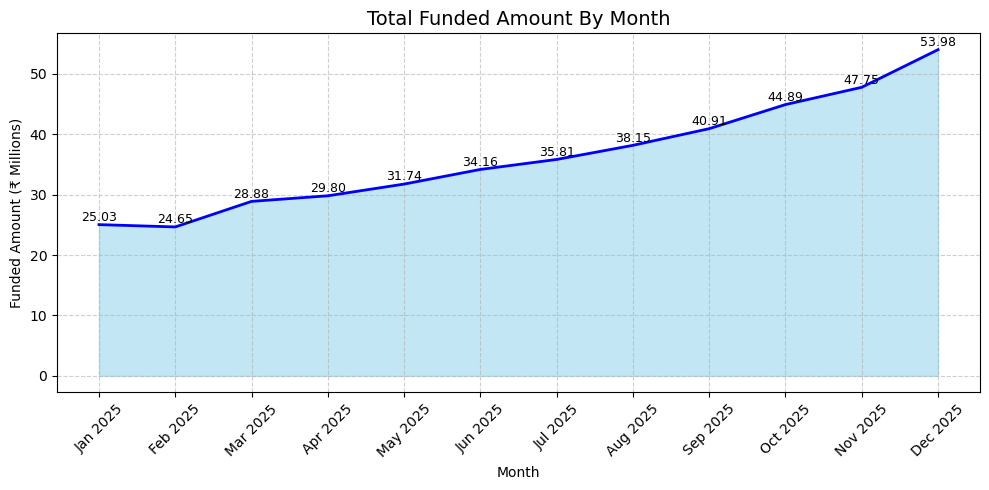

In [220]:
monthly_funded = (
    df.sort_values('issue_date')
      .assign(month_name = lambda x:x['issue_date'].dt.strftime('%b %Y'))
      .groupby('month_name' , sort=False)['loan_amount']
      .sum()
      .div(1000000)
      .reset_index(name='loan_amount_millions')
)

plt.figure(figsize=(10,5))
plt.fill_between(monthly_funded['month_name'],monthly_funded['loan_amount_millions'],color='skyblue',alpha=0.5)
plt.plot(monthly_funded['month_name'],monthly_funded['loan_amount_millions'],color='blue',linewidth = 2)

# to add the labels
for i,row in monthly_funded.iterrows():
    plt.text(i,row['loan_amount_millions']+ 0.1,f"{row['loan_amount_millions']:.2f}",
             ha='center',va='bottom' ,fontsize = 9, rotation = 0 , color = 'black')

# Fixed indentation - these were inside the for loop causing multiple graphs
plt.title('Total Funded Amount By Month', fontsize=14)
plt.xlabel('Month')
plt.ylabel('Funded Amount (₹ Millions)')
plt.xticks(ticks =range(len(monthly_funded)), labels = monthly_funded['month_name'], rotation = 45)
plt.grid(True, linestyle='--', alpha = 0.6)  # Fixed parameter name from linespace to linestyle
plt.tight_layout()
plt.show()

### Monthly Trends By Issue Date For Total Amount Received

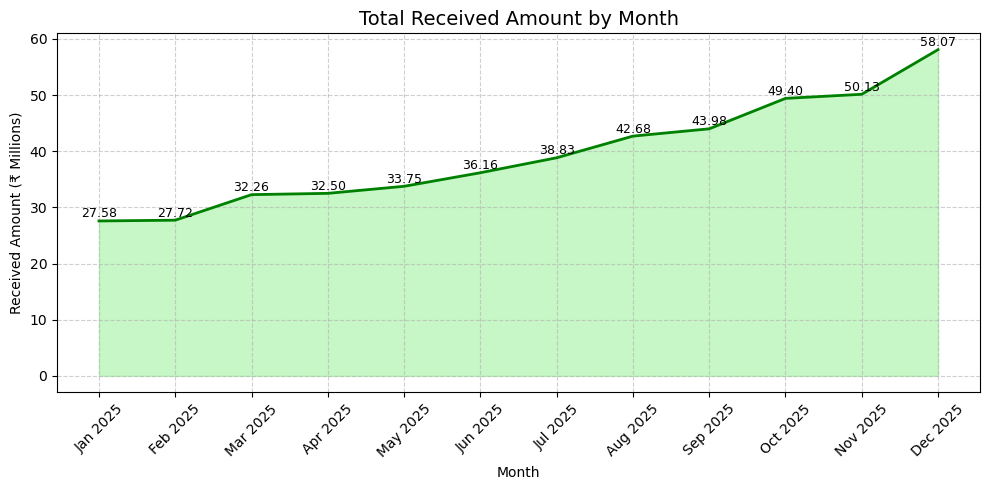

In [221]:
monthly_received = (
    df.sort_values('issue_date')
      .assign(month_name=lambda x: x['issue_date'].dt.strftime('%b %Y'))
      .groupby('month_name', sort=False)['total_payment']
      .sum()
      .div(1000000)
      .reset_index(name='received_amount_in_millions')
)

plt.figure(figsize=(10, 5))
plt.fill_between(monthly_received['month_name'], monthly_received['received_amount_in_millions'], color='lightgreen', alpha=0.5)
plt.plot(monthly_received['month_name'], monthly_received['received_amount_in_millions'], color='green', linewidth=2)

# Fixed the iteration through monthly_received DataFrame
for i, row in monthly_received.iterrows():
    plt.text(i, row['received_amount_in_millions'] + 0.1, f"{row['received_amount_in_millions']:.2f}",
            ha='center', va='bottom', fontsize=9, rotation=0, color='black')

plt.title('Total Received Amount by Month', fontsize=14)
plt.xlabel('Month')
plt.ylabel('Received Amount (₹ Millions)')
plt.xticks(ticks=range(len(monthly_received)), labels=monthly_received['month_name'], rotation=45)  # Fixed xtricks to xticks
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

### Monthly Trends by Issue Date for Total Loan Applications

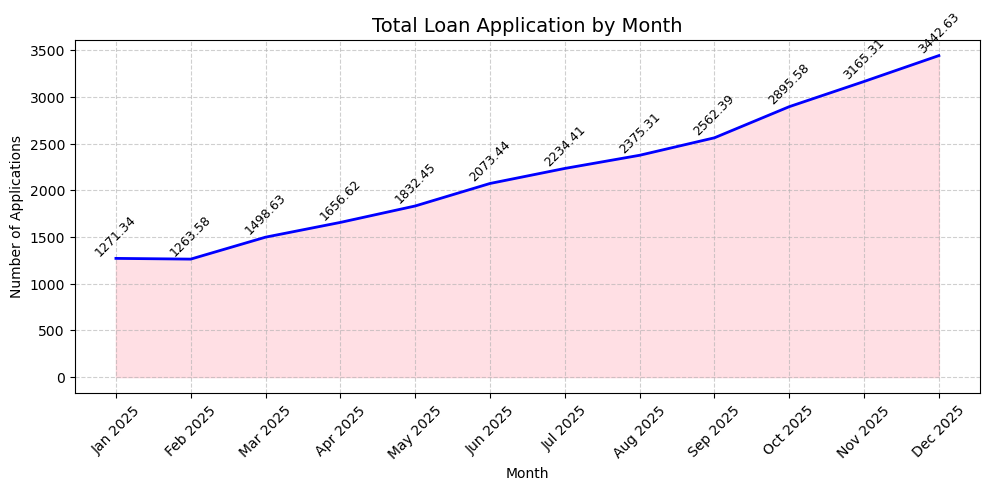

In [136]:
monthly_applications = (
    df.sort_values('issue_date')
      .assign(month_name=lambda x: x['issue_date'].dt.strftime('%b %Y'))
      .groupby('month_name',sort=False)['id']
      .sum()
      .div(1000000)
      .reset_index(name='loan_application_count')
)

plt.figure(figsize=(10,5))
plt.fill_between(monthly_applications['month_name'],monthly_applications['loan_application_count'],color='pink',alpha=0.5)
plt.plot(monthly_applications['month_name'],monthly_applications['loan_application_count'],color='blue',linewidth=2)


for i, row in monthly_applications.iterrows():
    plt.text(i,row['loan_application_count']+0.5,f"{row['loan_application_count']:.2f}",
            ha='center',va='bottom',fontsize = 9,color = 'black',rotation=45)


plt.title('Total Loan Application by Month',fontsize=14)
plt.xlabel('Month')
plt.ylabel('Number of Applications')
plt.xticks(ticks=range(len(monthly_applications)),labels = monthly_applications['month_name'],rotation=45)
plt.grid(True,linestyle = '--',alpha=0.6)
plt.tight_layout()
plt.show()


### Regional Analysis by State for Total Funded Amount

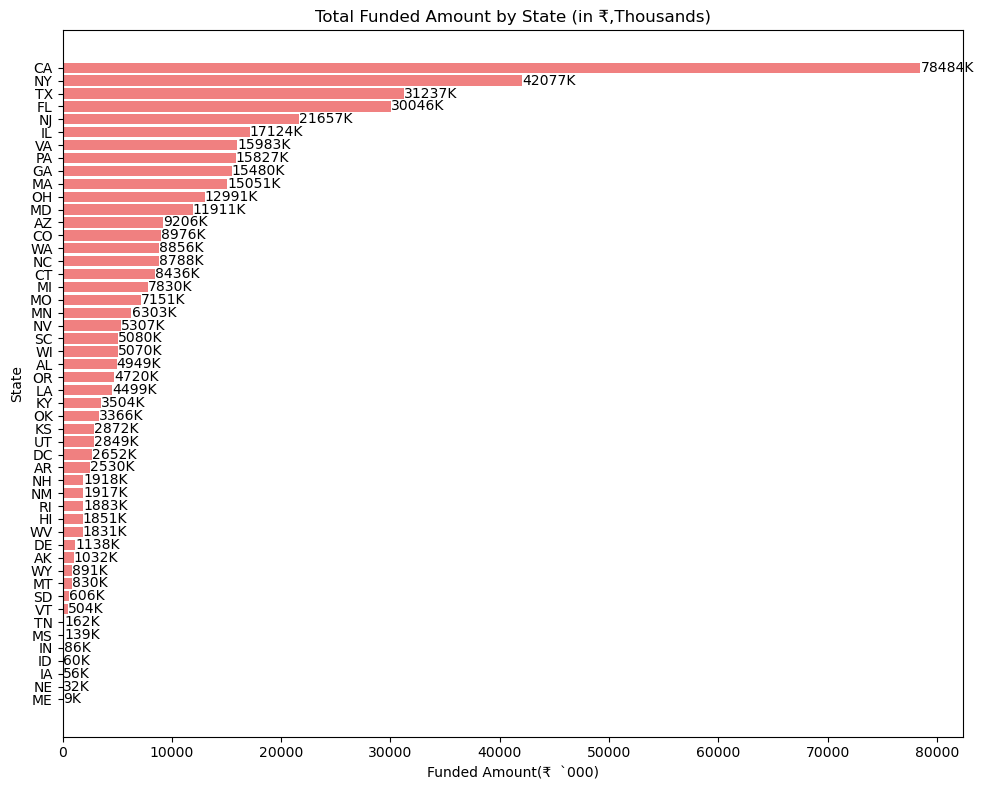

In [225]:
state_funding = df.groupby('address_state')['loan_amount'].sum().sort_values(ascending=True)
state_funding_in_thousands = state_funding/1000

plt.figure(figsize=(10,8))
bars=plt.barh(state_funding_in_thousands.index,state_funding_in_thousands.values,color='lightcoral')

for bar in bars:
    width=bar.get_width()
    plt.text(width + 10 ,bar.get_y() + bar.get_height()/2,f"{width:.0f}K",
            color='black',va='center')


plt.title('Total Funded Amount by State (in ₹,Thousands)')
plt.xlabel('Funded Amount(₹  `000)')
plt.ylabel('State')
plt.tight_layout()
plt.show()


### Regional Analysis by State for Total Amount Received

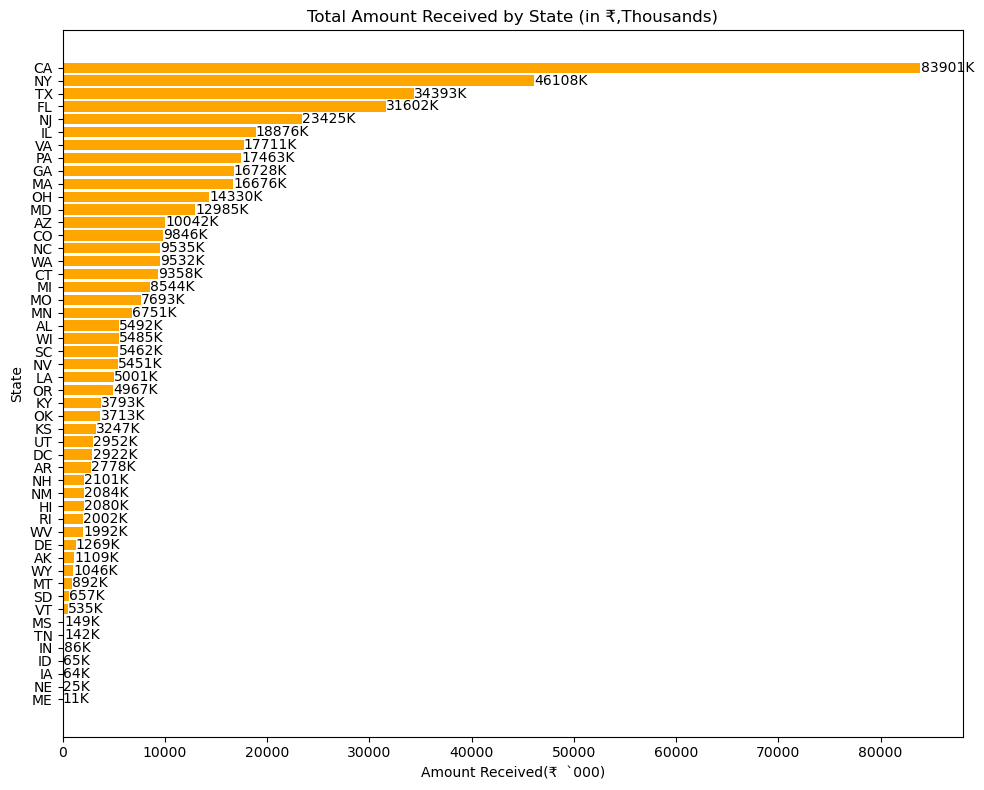

In [224]:
state_amount_received = df.groupby('address_state')['total_payment'].sum().sort_values(ascending=True)
state_amount_received_in_thousands = state_amount_received/1000

plt.figure(figsize=(10,8))
bars=plt.barh(state_amount_received_in_thousands.index,state_amount_received_in_thousands.values,color='orange')

for bar in bars:
    width=bar.get_width()
    plt.text(width + 10 ,bar.get_y() + bar.get_height()/2,f"{width:.0f}K",
            color='black',va='center')


plt.title('Total Amount Received by State (in ₹,Thousands)')
plt.xlabel('Amount Received(₹  `000)')
plt.ylabel('State')
plt.tight_layout()
plt.show()


### Regional Analysis by State for Total Applications

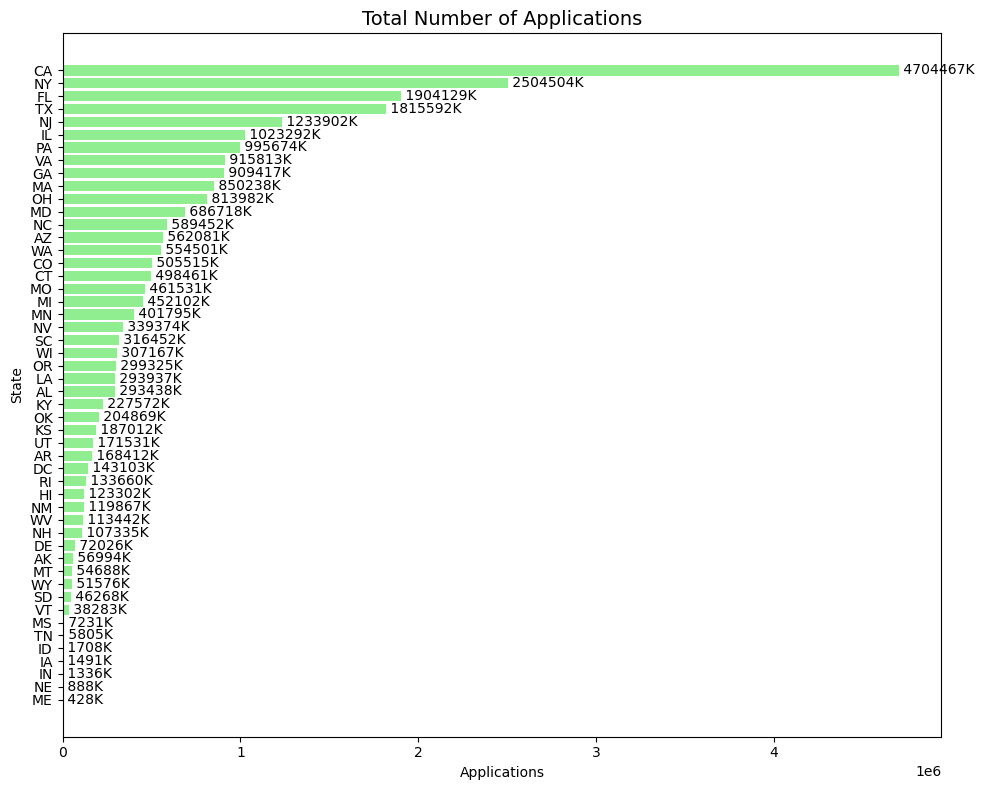

In [139]:
state_applications = df.groupby('address_state')['id'].sum().sort_values(ascending=True)
state_applications_in_thousands=state_applications/1000

plt.figure(figsize=(10,8))
bars=plt.barh(state_applications_in_thousands.index,state_applications_in_thousands.values,
             color='lightgreen')
for bar in bars:
    width=bar.get_width()
    plt.text(width + 10,bar.get_y() + bar.get_height()/2,
            f"{width: .0f}K", color='black',va='center')


plt.title('Total Number of Applications',fontsize=14)
plt.xlabel('Applications')
plt.ylabel('State')
plt.tight_layout()
plt.show()

### Loan Term Analysis Total Funded Amount

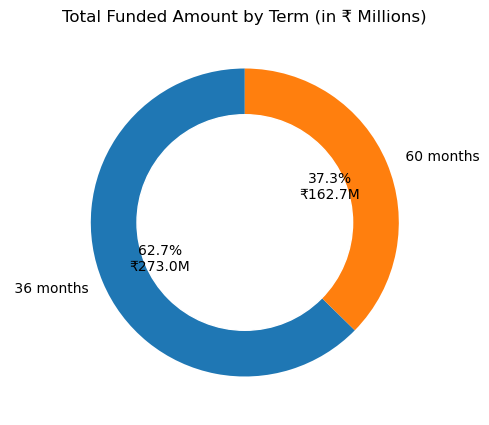

In [226]:
term_funding_millions= df.groupby('term')['loan_amount'].sum() / 1000000

plt.figure(figsize=(5,5))
plt.pie(
    term_funding_millions,labels=term_funding_millions.index,
    autopct = lambda p: f"{p:.1f}%\n₹{p*sum(term_funding_millions)/100:.1f}M",
    startangle=90,wedgeprops={'width':0.4}
)

plt.gca().add_artist(plt.Circle((0,0),0.70,color='white')) # to convert it into Donut Chart
plt.title("Total Funded Amount by Term (in ₹ Millions)")
plt.show()

### Loan Term Analysis Total Amount Received

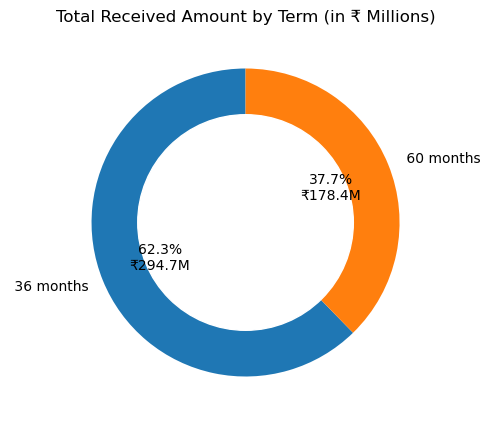

In [227]:
term_received_amount_millions= df.groupby('term')['total_payment'].sum() / 1000000

plt.figure(figsize=(5,5))
plt.pie(
    term_received_amount_millions,labels=term_received_amount_millions.index,
    autopct = lambda p: f"{p:.1f}%\n₹{p*sum(term_received_amount_millions)/100:.1f}M",
    startangle=90,wedgeprops={'width':0.4}
)

plt.gca().add_artist(plt.Circle((0,0),0.70,color='white')) # to convert it into Donut Chart
plt.title("Total Received Amount by Term (in ₹ Millions)")
plt.show()

### Loan Term Analysis Total Loan Applications

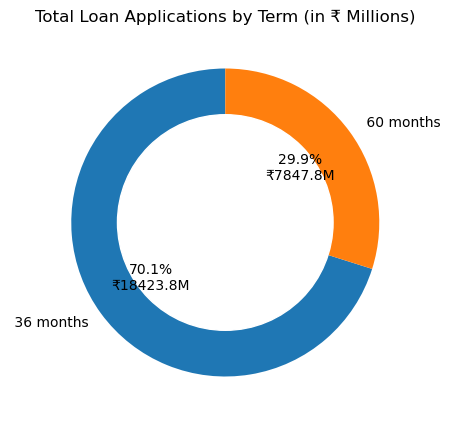

In [228]:
term_loan_applications= df.groupby('term')['id'].sum() / 1000000

plt.figure(figsize=(5,5))
plt.pie(
    term_loan_applications,labels=term_loan_applications.index,
    autopct = lambda p: f"{p:.1f}%\n₹{p*sum(term_loan_applications)/100:.1f}M",
    startangle=90,wedgeprops={'width':0.4}
)

plt.gca().add_artist(plt.Circle((0,0),0.70,color='white')) # to convert it into Donut Chart
plt.title("Total Loan Applications by Term (in ₹ Millions)")
plt.show()

### Employee Length by Total Funded Amount

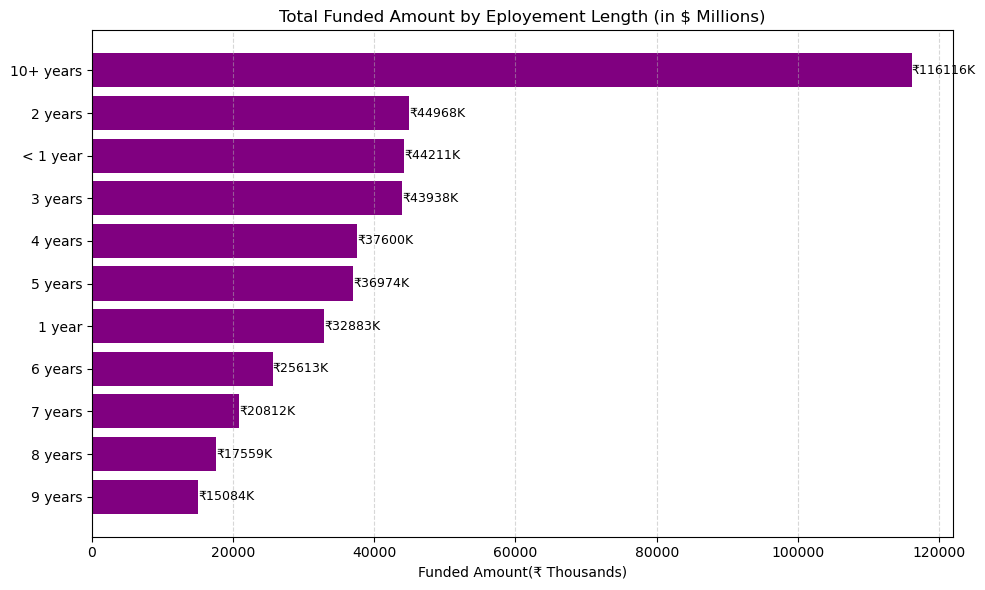

In [229]:
emp_funding_thousands= df.groupby('emp_length')['loan_amount'].sum().sort_values()/1000

plt.figure(figsize=(10,6))
bars=plt.barh(emp_funding_thousands.index,emp_funding_thousands,color='purple')

for bar in bars:
    width=bar.get_width()
    plt.text(width + 10 ,bar.get_y() + bar.get_height()/2,
             f"₹{width:.0f}K",va='center',fontsize=9)
    
plt.title("Total Funded Amount by Eployement Length (in $ Millions)")
plt.xlabel("Funded Amount(₹ Thousands)")
plt.grid(axis='x',linestyle='--',alpha=0.5)
plt.tight_layout()

plt.show()

### Employee Length by Total Amount Received

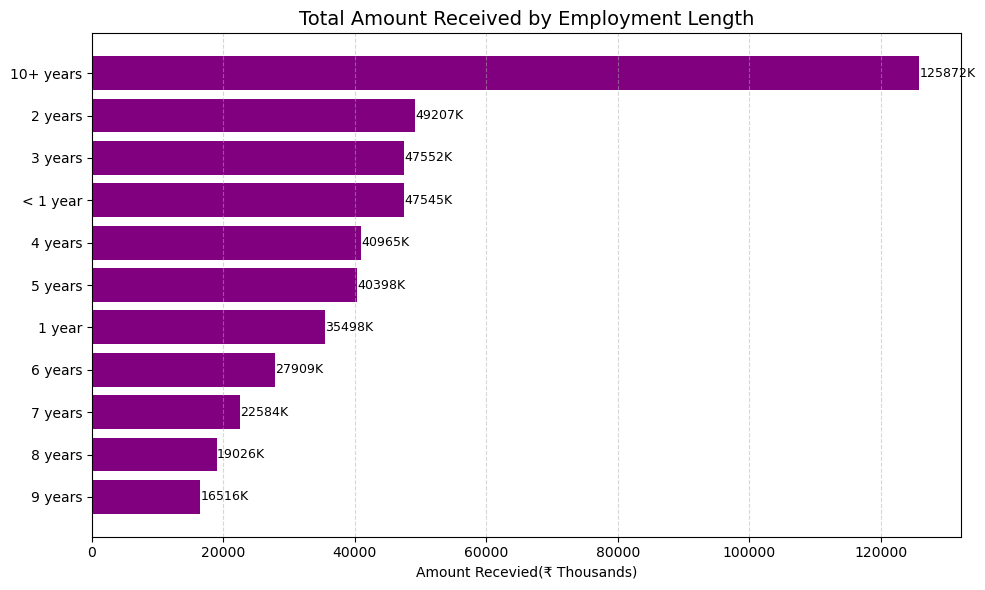

In [230]:
emp_received_thousands = df.groupby('emp_length')['total_payment'].sum().sort_values() /1000

plt.figure(figsize=(10,6))
bars=plt.barh(emp_received_thousands.index,emp_received_thousands,color='purple')

for bar in bars:
    width=bar.get_width()
    plt.text(width+10,bar.get_y() + bar.get_height()/2,
             f"{width:.0f}K",fontsize=9,va='center')

plt.title("Total Amount Received by Employment Length",fontsize=14)
plt.xlabel("Amount Recevied(₹ Thousands)")
plt.grid(axis='x',linestyle='--',alpha=0.5)
plt.tight_layout()
plt.show()


### Employee Length by Total Applications

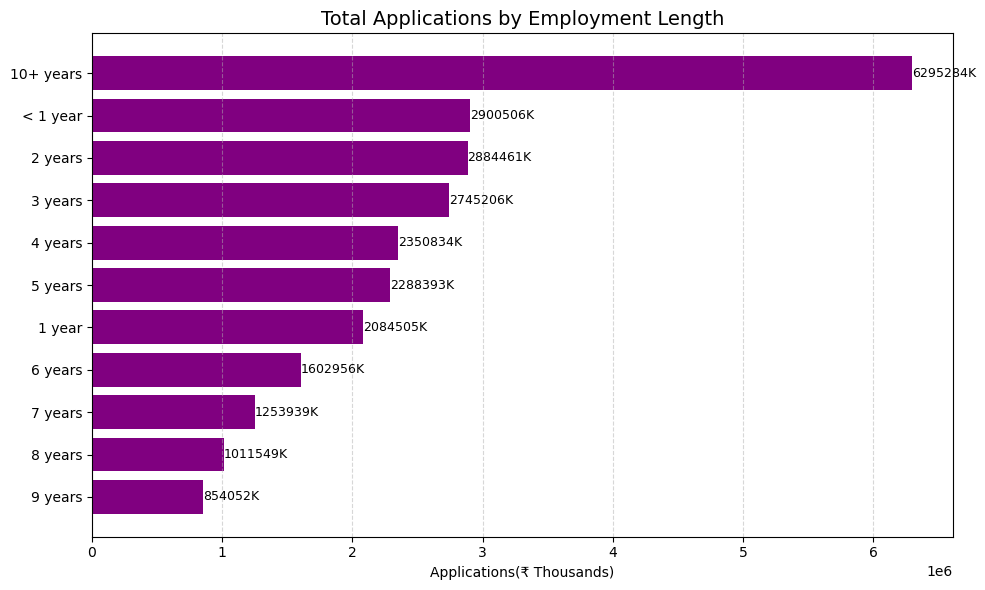

In [231]:
emp_applications_thousands = df.groupby('emp_length')['id'].sum().sort_values() /1000

plt.figure(figsize=(10,6))
bars=plt.barh(emp_applications_thousands.index,emp_applications_thousands,color='purple')

for bar in bars:
    width=bar.get_width()
    plt.text(width+10,bar.get_y() + bar.get_height()/2,
             f"{width:.0f}K",fontsize=9,va='center')

plt.title("Total Applications by Employment Length",fontsize=14)
plt.xlabel("Applications(₹ Thousands)")
plt.grid(axis='x',linestyle='--',alpha=0.5)
plt.tight_layout()
plt.show()


### Loan Purpose Breakdown by Total Applications

### Loan Purpose Breakdown by Total Total Funded Amount

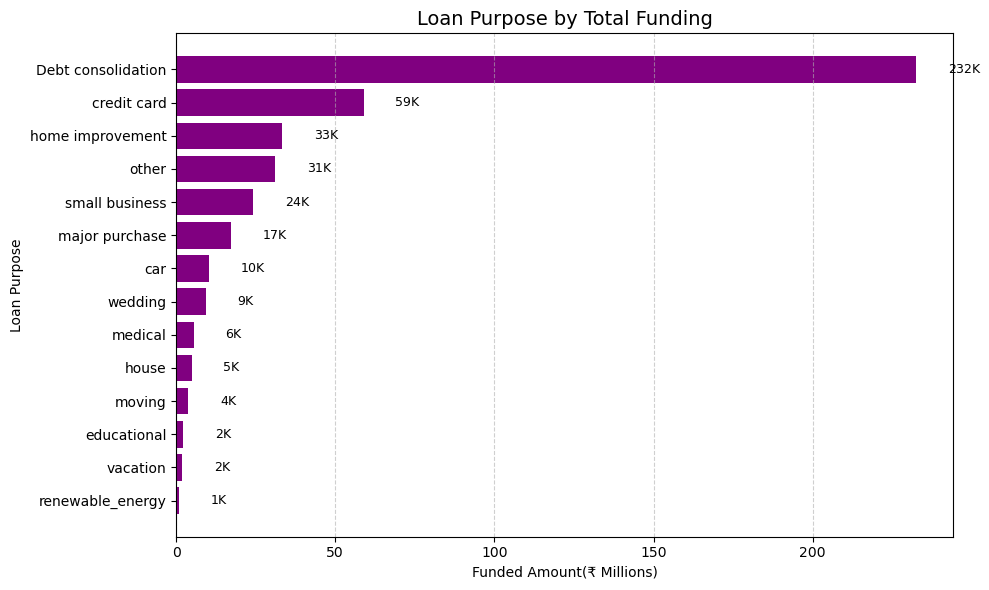

In [232]:
purpose_funding_millions = df.groupby('purpose')['loan_amount'].sum().sort_values() /1000000

plt.figure(figsize=(10,6))
bars=plt.barh(purpose_funding_millions.index,purpose_funding_millions,color='purple')

for bar in bars:
    width=bar.get_width()
    plt.text(width+10,bar.get_y() + bar.get_height()/2,
             f"{width:.0f}K",fontsize=9,va='center')

plt.title("Loan Purpose by Total Funding",fontsize=14)
plt.xlabel("Funded Amount(₹ Millions)")
plt.ylabel("Loan Purpose")
plt.grid(axis='x',linestyle='--',alpha=0.6)
plt.tight_layout()
plt.show()


### Loan Purpose Breakdown by Total Total Amount Recevied

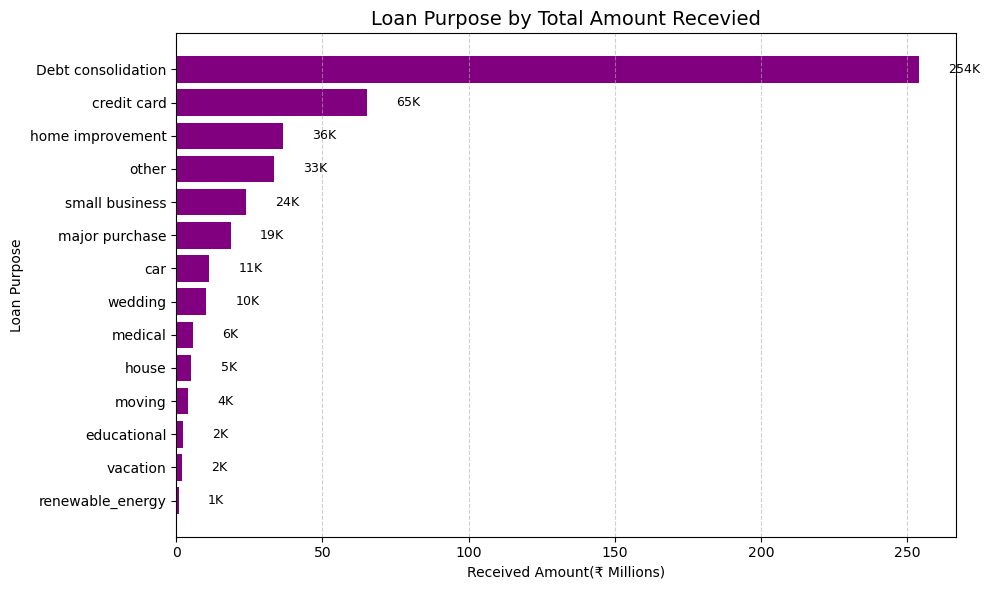

In [233]:
purpose_funding_millions = df.groupby('purpose')['total_payment'].sum().sort_values() /1000000

plt.figure(figsize=(10,6))
bars=plt.barh(purpose_funding_millions.index,purpose_funding_millions,color='purple')

for bar in bars:
    width=bar.get_width()
    plt.text(width+10,bar.get_y() + bar.get_height()/2,
             f"{width:.0f}K",fontsize=9,va='center')

plt.title("Loan Purpose by Total Amount Recevied",fontsize=14)
plt.xlabel("Received Amount(₹ Millions)")
plt.ylabel("Loan Purpose")
plt.grid(axis='x',linestyle='--',alpha=0.6)
plt.tight_layout()
plt.show()


### Loan Purpose Breakdown by Total Applications

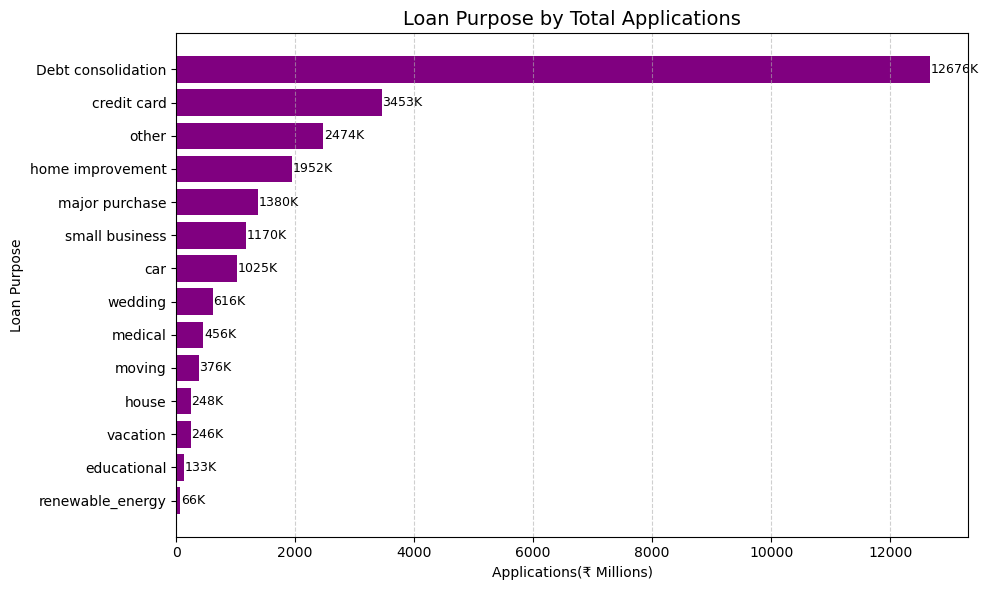

In [234]:
purpose_funding_millions = df.groupby('purpose')['id'].sum().sort_values() /1000000

plt.figure(figsize=(10,6))
bars=plt.barh(purpose_funding_millions.index,purpose_funding_millions,color='purple')

for bar in bars:
    width=bar.get_width()
    plt.text(width+10,bar.get_y() + bar.get_height()/2,
             f"{width:.0f}K",fontsize=9,va='center')

plt.title("Loan Purpose by Total Applications",fontsize=14)
plt.xlabel("Applications(₹ Millions)")
plt.ylabel("Loan Purpose")
plt.grid(axis='x',linestyle='--',alpha=0.6)
plt.tight_layout()
plt.show()


### Home Ownership by Total Funding Amount

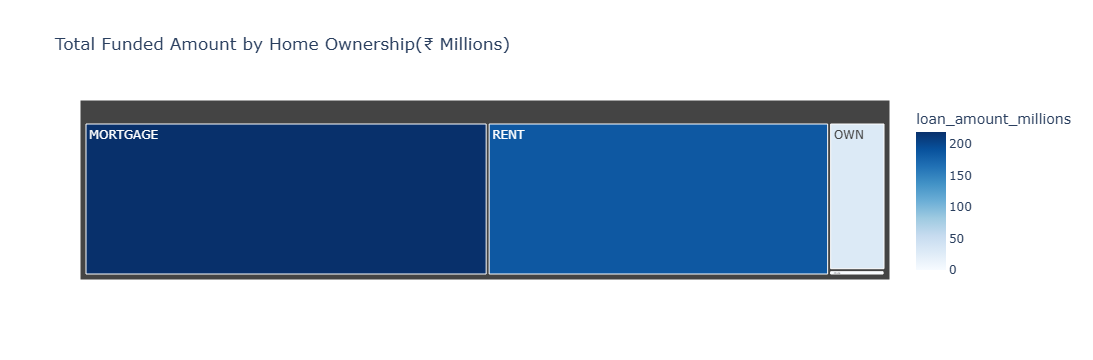

In [235]:
home_funding= df.groupby('home_ownership')['loan_amount'].sum().reset_index()
home_funding['loan_amount_millions']= home_funding['loan_amount']/ 1000000

fig =px.treemap(
    home_funding,
    path=['home_ownership'],
    values='loan_amount_millions',
    color='loan_amount_millions',
    color_continuous_scale='blues',
    title='Total Funded Amount by Home Ownership(₹ Millions)'
)
fig.show()

### Home Ownership by Total Amount Received

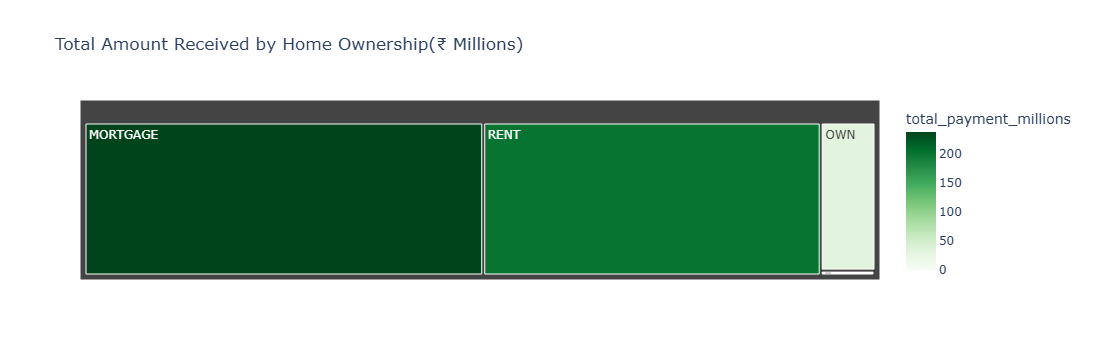

In [236]:
home_amount_received = df.groupby('home_ownership')['total_payment'].sum().reset_index()
home_amount_received['total_payment_millions']=home_amount_received['total_payment']/1000000

fig = px.treemap(
    home_amount_received,
    path=['home_ownership'],
    values='total_payment_millions',
    color='total_payment_millions',
    color_continuous_scale='greens',
    title='Total Amount Received by Home Ownership(₹ Millions)'
)

fig.show()

### Home Ownership by Total Applications

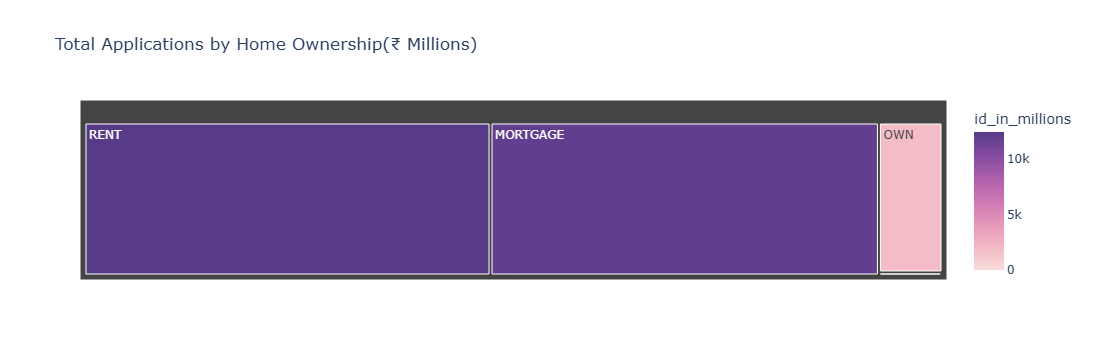

In [237]:
home_applications = df.groupby('home_ownership')['id'].sum().reset_index()
home_applications['id_in_millions']=home_applications['id']/1000000

fig = px.treemap(
    home_applications,
    path=['home_ownership'],
    values='id_in_millions',
    color='id_in_millions',
    color_continuous_scale='purpor',
    title='Total Applications by Home Ownership(₹ Millions)'
)

fig.show()